# 04 - DistilBERT Sentiment Demonstration

This notebook demonstrates the transformer-based sentiment-analysis
component of the research framework.

DistilBERT is used as a more context-sensitive NLP approach compared
with the rule-based VADER baseline and the traditional TF-IDF +
Logistic Regression approach.

The implementation uses the pretrained
`distilbert-base-uncased-finetuned-sst-2-english` model for technical
demonstration.

This model has not been fine-tuned on the proposed gacha-game Reddit
dataset. Therefore, the predictions produced in this notebook are
demonstration outputs and must not be interpreted as empirical findings
about player sentiment.

Final empirical evaluation would require an appropriately authorised
and ethically approved research dataset and a defined training and
evaluation procedure.

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.distilbert_sentiment import (
    DEFAULT_MODEL_NAME,
    create_pipeline,
    predict,
)

In [2]:
print("DistilBERT model:")
print(DEFAULT_MODEL_NAME)

DistilBERT model:
distilbert-base-uncased-finetuned-sst-2-english


In [3]:
classifier = create_pipeline()

print("DistilBERT sentiment pipeline created successfully.")

c:\Users\Simz\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13698.27it/s]


DistilBERT sentiment pipeline created successfully.


In [4]:
example_text = (
    "I really like the character, but the banner pity system "
    "feels too expensive."
)

result = classifier(example_text)

result

[{'label': 'NEGATIVE', 'score': 0.999427855014801}]

In [5]:
texts = [
    "I really love this character and the banner was very generous.",
    "The pity system is awful and costs far too much.",
    "The banner is available for three weeks.",
    "I lost my 50/50 again and I am extremely disappointed.",
    "The free rewards this update are actually pretty good.",
]

predictions = predict(texts)

predictions

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13805.35it/s]


[{'label': 'POSITIVE', 'score': 0.9998748302459717},
 {'label': 'NEGATIVE', 'score': 0.9997795224189758},
 {'label': 'NEGATIVE', 'score': 0.9163124561309814},
 {'label': 'NEGATIVE', 'score': 0.9997977614402771},
 {'label': 'POSITIVE', 'score': 0.9998446702957153}]

## Model Output Classes

The pretrained DistilBERT checkpoint used for this technical
demonstration was trained for binary sentiment classification.

Its output therefore consists primarily of:

- POSITIVE
- NEGATIVE

This differs from the proposed research annotation scheme of:

- Positive
- Neutral
- Negative

Consequently, the pretrained model is demonstrated here only as a
technical transformer-based component. A final empirical research
implementation would require an appropriate training strategy to
support the three-class sentiment scheme, such as fine-tuning a
transformer model using the manually labelled research dataset.

In [6]:
distilbert_results = pd.DataFrame(predictions)

distilbert_results

,label,score
0,POSITIVE,0.999875
1,NEGATIVE,0.999780
2,NEGATIVE,0.916312
3,NEGATIVE,0.999798
4,POSITIVE,0.999845


In [7]:
distilbert_output = pd.DataFrame({
    "text": texts,
    "distilbert_label": [
        result["label"]
        for result in predictions
    ],
    "distilbert_score": [
        result["score"]
        for result in predictions
    ],
})

distilbert_output

,text,distilbert_label,distilbert_score
0,I really love this character and the banner wa...,POSITIVE,0.999875
1,The pity system is awful and costs far too much.,NEGATIVE,0.999780
2,The banner is available for three weeks.,NEGATIVE,0.916312
3,I lost my 50/50 again and I am extremely disap...,NEGATIVE,0.999798
4,The free rewards this update are actually pret...,POSITIVE,0.999845


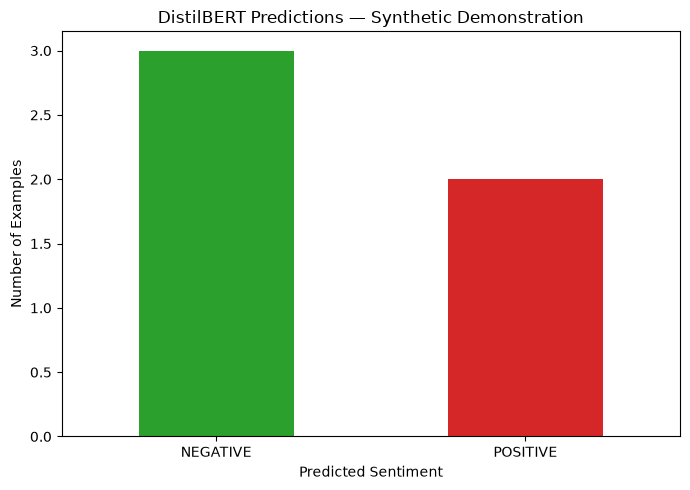

In [8]:
import matplotlib.pyplot as plt

label_counts = distilbert_output["distilbert_label"].value_counts()

label_counts.plot(
    kind="bar",
    color=["#2ca02c", "#d62728"],
    figsize=(7, 5),
)

plt.title(
    "DistilBERT Predictions — Synthetic Demonstration"
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
distilbert_output.sort_values(
    "distilbert_score",
    ascending=False
)

mean_confidence = distilbert_output["distilbert_score"].mean()

print(
    f"Mean demonstration confidence: "
    f"{mean_confidence:.3f}"
)

Mean demonstration confidence: 0.983


In [10]:
DATA_PATH = PROJECT_ROOT / "data" / "sample_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

df.head()

sample_predictions = predict(
    df["text"].tolist()
)

distilbert_sample_output = pd.DataFrame({
    "text": df["text"],
    "distilbert_label": [
        result["label"]
        for result in sample_predictions
    ],
    "distilbert_score": [
        result["score"]
        for result in sample_predictions
    ],
})

distilbert_sample_output.head()

Dataset shape: (9, 3)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12561.77it/s]


,text,distilbert_label,distilbert_score
0,The pity system is really helpful and makes pu...,POSITIVE,0.920632
1,The banner rates feel terrible and I spent far...,NEGATIVE,0.999674
2,I saved enough primogems for the next character.,NEGATIVE,0.962908
3,I actually like the pity system because I know...,NEGATIVE,0.995175
4,The cost of pulls is ridiculous for free to pl...,NEGATIVE,0.999422


In [11]:
distilbert_sample_output[
    "distilbert_label"
].value_counts()

distilbert_label
NEGATIVE    7
POSITIVE    2
Name: count, dtype: int64

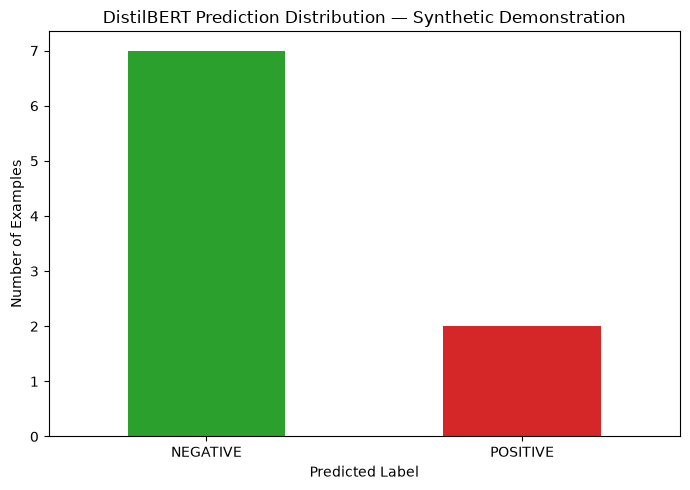

In [12]:
distilbert_sample_output[
    "distilbert_label"
].value_counts().plot(
    kind="bar",
    color=["#2ca02c", "#d62728"],
    figsize=(7, 5),
)

plt.title(
    "DistilBERT Prediction Distribution — Synthetic Demonstration"
)

plt.xlabel("Predicted Label")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Limitations of the Demonstration

Several limitations apply to the DistilBERT demonstration.

First, the pretrained checkpoint used here was developed for general
sentiment classification rather than specifically for gacha-game
discussion.

Second, the checkpoint uses binary sentiment labels rather than the
three-class Positive, Neutral and Negative scheme proposed for the
research project.

Third, the model has not been fine-tuned using manually labelled
gacha-game Reddit comments.

Fourth, the demonstration data are synthetic and therefore cannot be
used to make claims about actual player sentiment.

These limitations mean that the current implementation demonstrates
the technical feasibility of transformer-based sentiment inference but
does not constitute the final empirical DistilBERT evaluation proposed
by the research methodology.

## Proposed Empirical Implementation

Following ethical approval and authorised data access, the intended
empirical workflow would be:

1. Collect the authorised Reddit dataset.
2. Apply the predefined inclusion and exclusion criteria.
3. Manually label the required training and evaluation data.
4. Split the labelled data into training, validation and test sets.
5. Select an appropriate pretrained transformer checkpoint.
6. Fine-tune the model using the manually labelled training data.
7. Evaluate the model on the held-out test set.
8. Calculate precision, recall and macro-F1.
9. Generate a confusion matrix.
10. Compare the transformer results with VADER and TF-IDF +
    Logistic Regression.

The final empirical implementation would therefore differ from the
pretrained inference demonstration presented in this notebook.

## Conclusion

This notebook demonstrates that the project's transformer-based
sentiment-analysis component can load a pretrained DistilBERT model and
generate sentiment predictions for textual input.

The implementation successfully provides:

- pretrained model loading;
- text tokenisation and inference through Hugging Face Transformers;
- sentiment labels;
- prediction confidence scores; and
- batch prediction functionality.

However, the demonstrated checkpoint is a general binary sentiment
model and has not been fine-tuned on the proposed gacha-game Reddit
dataset.

Therefore, the notebook demonstrates technical implementation rather
than empirical research findings.

The final research evaluation remains dependent on ethical approval,
authorised data collection and subsequent model fine-tuning and
evaluation.